In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
d = pd.read_csv('online_shoppers_intention.csv')
d.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


В данной части проекта мы будем работать с датасетом поведения посетителей интернет-магазина. В датасете 18 признаков:

Administrative - Количество просмотренных пользователем административных страниц, типа аккаунт, настройки, личный кабинет и тд.

Administrative_Duration - Сколько времени пользователь провел на административных страницах.

Informational - Количество просмотренных пользователем страниц с информацией, например, доставка, гарантии, часто задаваемые вопросы и тд.

Informational_Duration - Время на информационных страницах.

ProductRelated - Количество просмотренных товарных страниц.

ProductRelated_Duration - Время на страницах товаров.

BounceRates - Показатель, характеризующий "нервозность" покупателя: например, у человека, который часто заходит и сразу выходит со страничек товаров данный показатель высокий.

ExitRates - Частота выхода со страниц.

PageValues - Показатель, обозначающий ценность страницы. Чем выше ценность, тем ближе пользователь к покупке.

SpecialDay - Близость текущей даты к праздничной.

Month - Месяц посещения.

OperatingSystems - Операционная система пользователя.

Browser - Браузер пользователя.

Region - Регион пользователя.

TrafficType - Источник посещения пользователя.

VisitorType - Является ли пользователь новым посетителем или возвращающимся пользователем.

Weekend - Было ли посещение в выходной или нет.

Revenue - Совершил ли пользователь покупку.

In [4]:
d.shape

(12330, 18)

In [5]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
d.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [7]:
d.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
d.describe(include='object')

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [9]:
for i in ['OperatingSystems','Browser','Region','TrafficType']:
    print(i)
    print(d[i].value_counts())
    print()

OperatingSystems
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

Browser
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

Region
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64

TrafficType
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64



В целом датасет соответствует названию: он действительно содержит информацию о пользовательских сессиях в неком интернет магазине. Объем признаков и количество наблюдений соответствую необходимым критериям. Пропуски в датасете отсутствуют. Также была проведена интеллектуальная оценка информативности и единственная проблема, замеченная на текущем этапе взаимодействия с данными - 4 признака, которые тяжело интерпретировать: OperatingSystems, Browser, Region, TrafficType. В датасете они представлены, как категориальные и имеют числовые значения от единицы, но при этом нигде не упомянуто какое значение обозначает конкретную категорию, что по факту делает бесполезным с точки зрения бизнеса использование данных признаков. Ссылка на датасет: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset.  Мы можем обращаться с этими признаками, как с мнимым представлением, например, мы бы могли поставить некоторую гипотезу, подтверждение которой бы звучало так: "Люди, пользующиеся браузером 1 совершают покупку чаще, чем пользователи брузера 2". В теории данный вид аналитики имеет место быть для учебных целей, но лучше мы сделаем выбор в пользу возможности  гипотетического практического применения гипотез, которые будут сформулированы в ходе выполнения проекта. В связи со всем вышеупомянутым избавимся от этих колонок.

In [10]:
d = d.drop(columns=['OperatingSystems', 'Browser', 'Region', 'TrafficType'])
d.shape

(12330, 14)

In [11]:
d.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,Returning_Visitor,True,False


В других признаках на первый взгляд проблем нет, поэтому можем переходить к исследовательскому анализу данных.

**EDA**

Посмотрим, сколько пользователей вообще доходят до этапа покупки из общего числа

In [12]:
d['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [13]:
d['Revenue'].value_counts(normalize=True)

,proportion
Revenue,
False,0.845255
True,0.154745


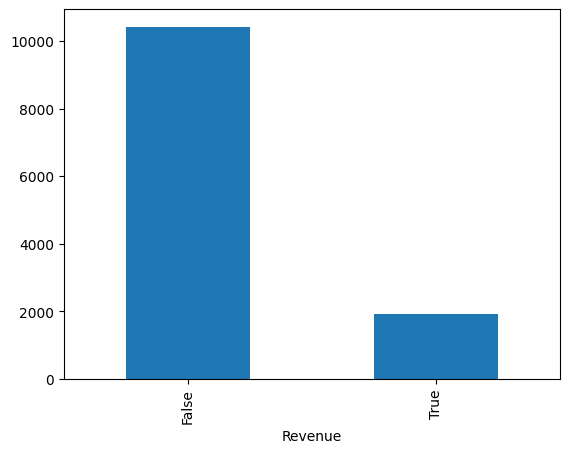

In [14]:
d['Revenue'].value_counts().plot(kind='bar')
plt.show()

In [16]:
d['VisitorType'].value_counts()

,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


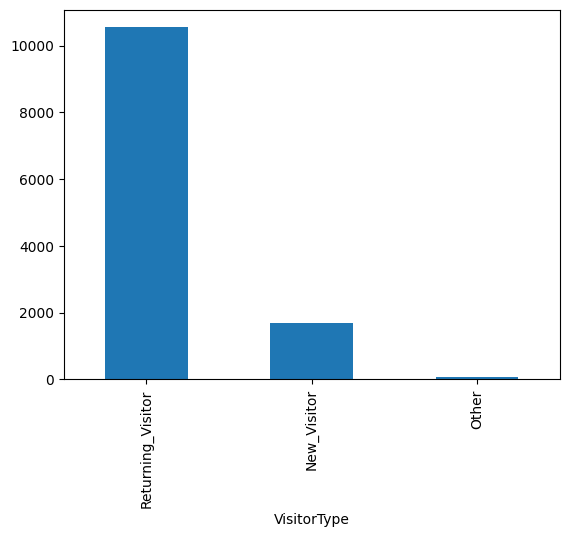

In [17]:
d['VisitorType'].value_counts().plot(kind='bar')
plt.show()

In [18]:
d['Month'].value_counts()

,count
Month,
May,3364
Nov,2998
Mar,1907
Dec,1727
Oct,549
Sep,448
Aug,433
Jul,432
June,288


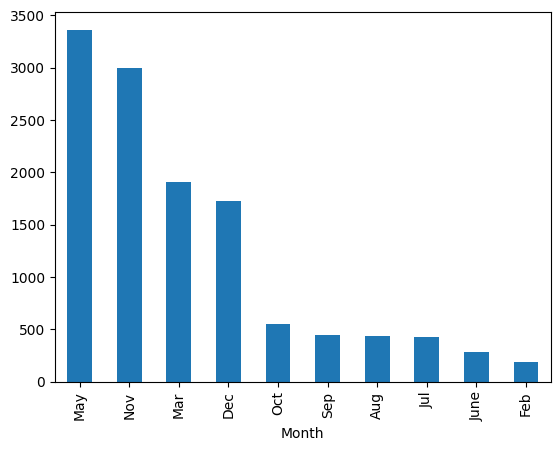

In [19]:
d['Month'].value_counts().plot(kind='bar')
plt.show()

In [20]:
d['Weekend'].value_counts()

,count
Weekend,
False,9462
True,2868


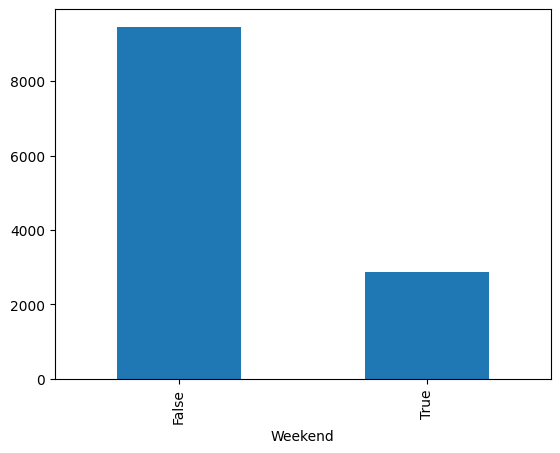

In [21]:
d['Weekend'].value_counts().plot(kind='bar')
plt.show()

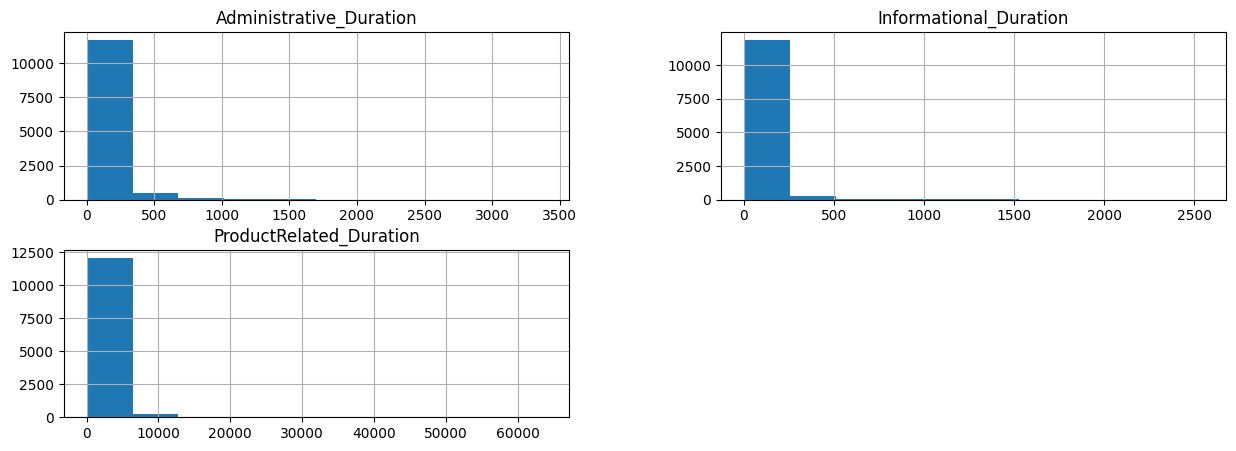

In [22]:
x = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration'
]

d[x].hist(figsize=(15,5))
plt.show()

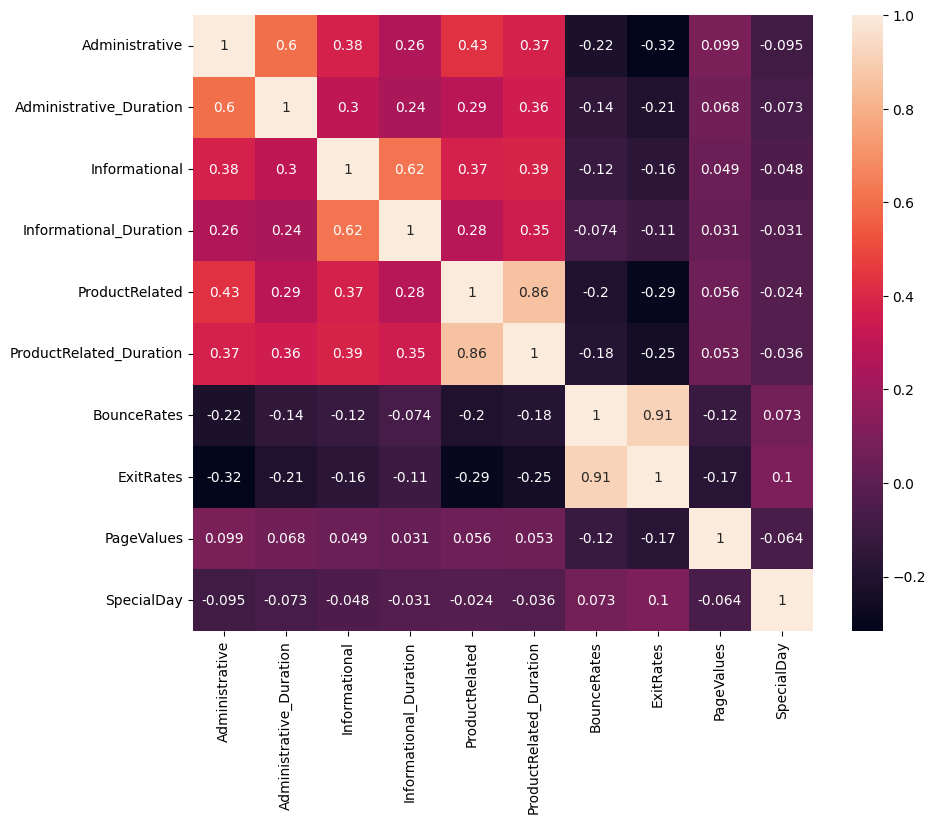

In [23]:
x = d.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(x.corr(), annot=True)
plt.show()

Выводы из проведенного EDA:

1. По графику выручки видно, что большинство пользователей не совершают покупку.

2. По графику типа пользователей можно заметить, что бОльшую часть аудитории составляют именно пользователи, повторно использующие сервис.

3. По графику месяцев видно, что данные распределены абсолютно неравномерно.

4. По графику Weekends можно заметить, что в основном сервис используется в будние дни.

5. Все графики длительностей посещения административных, информационных и товарных страниц имеют тенденцию на коротковременные визиты пользователей, и лишь изредка сессия юзера может превышать какой-то минимальный порог.

6. Корелляционный анализ показал, что есть выраженная зависимость между количеством просмотренных страниц одной структуры (информация, администрация или товары) и длительностью посещения их. Также самая сильная связь между признаками BounceRates и ExitRates, а признак SpecialDay почти никак не связан ни с одной другой характеристикой, что делает ее не особо привлекательной для исследования. Природа этих зависимостей довольно очевидна и наглядна.

Так как основной целью сбора данного датасета являлось определить факторы, влияющие на решение пользователя о покупке (Revenue), признаки VisitorType, Weekend, Month, ProductRelated_Duration, PageValues, BounceRates и ExitRates будут представлять наибольший интерес для дальнейшего анализа. Именно для этих признаков будет целесообразно формулировать статистические гипотезы, подтверждение которых может дать реальную картину взаимодействия пользователей с сайтом. Причем я полагаю, что собранный датасет имеет показатели, характеризующие не только конкретный сайт, но и большинство подобных, что добавляет бОльший практический интерес к проекту.

Вполне резонный и базовый вопрос, который может предоставить практическую значимость: "есть ли определенная сезонность нашего сайта?" Ответ на этот вопрос может помочь более грамотно распределить ресурсы компании, рекламный бюджет, и вовремя восполнять запасы на складах.

Гипотеза 1.

H0 - Доля покупок одинакова для каждого месяца

H1 - У товара есть сезонность

Также может быть поставлен такой вопрос: "Отличается ли поведение пользователей, совершивших покупку, от поведения пользователей, покинувших сайт без покупки?"

Гипотеза 2.

H0 - распределение ProductRelated_Duration одинаково для покупателей и непокупателей.

H1 - распределение ProductRelated_Duration различается для покупателей и непокупателей.

И еще "Отличается ли вероятность совершения покупки у новых и возвращающихся пользователей?"

Гипотеза 3.

H0 - Доля покупок среди новых и возвращающихся пользователей одинакова.

H1 - Доля покупок среди новых и возвращающихся пользователей различается.

Все три этих гипотезы имеют разную природу - это значит, что они касаются трех различных аспектов деятельности интернет-магазина. Также различны и методы проверки гипотез в связи с различием предмета исследования.

В первом случае, мы изучаем зависимость между двумя категориальными признаками, для это лучше подойдет использование критерия независимости X^2 (Хи-квадрат).

Вторая гипотеза рассматривает поведение пользователей на сайте, для проверки этой гипотезы наиболее подходящим является тест Манна-Уитни.

Третья гипотеза рассматривает различие в долях покупок между новыми и возвращающимися пользователями. Для анализа долей лучше всего подойдет z-тест.

**Проверка гипотез**

Гипотеза 1.

In [28]:
t = pd.crosstab(d['Month'], d['Revenue'])
t

Revenue,False,True
Month,,
Aug,357,76
Dec,1511,216
Feb,181,3
Jul,366,66
June,259,29
Mar,1715,192
May,2999,365
Nov,2238,760
Oct,434,115


In [29]:
from scipy.stats import chi2_contingency

In [30]:
s, p, a, e = chi2_contingency(t)

print(s)
print(p)

384.93476153599426
2.2387855164805443e-77


In [31]:
alpha = 0.05
if p < alpha:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

Отвергаем H0


Так как p-value проведенного тестирования оказался больше, чем alpha, то значит мы имеем статистические оснавания полагать, что на самом деле покупки обладают характеристикой сезонности.

In [32]:
x = d.groupby('Month')['Revenue'].mean().sort_values(ascending=False) * 100

x

,Revenue
Month,
Nov,25.350233
Oct,20.947177
Sep,19.196429
Aug,17.551963
Jul,15.277778
Dec,12.507238
May,10.850178
June,10.069444
Mar,10.068170


In [33]:
x = d.groupby('Month').agg({
    'Revenue':['count','mean']
})
x.columns = ['Visits','Conversion']
x['Conversion'] = x['Conversion'] * 100

x.sort_values('Conversion', ascending=False)

,Visits,Conversion
Month,,
Nov,2998,25.350233
Oct,549,20.947177
Sep,448,19.196429
Aug,433,17.551963
Jul,432,15.277778
Dec,1727,12.507238
May,3364,10.850178
June,288,10.069444
Mar,1907,10.068170


Получилась довольно интересная статистика, которая говорит о том, что пик совершения покупок в конце осени - ноябре, но при этом остальные осенние месяца имеют высокие значения. Летом конверсия находится на среднем уровне. Самый низкий показатель приходится на февраль - всего 1.63. На основе результатов этого исследования можно дать рекомендацию подготовить бОльшее количество запасов товаров к осенним месяцам, а в месяцы меньшей конверсии проводить больше маркетинговых мероприятий.

Гипотеза 2.

In [34]:
x = d[d['Revenue'] == True]['ProductRelated_Duration']
y = d[d['Revenue'] == False]['ProductRelated_Duration']

x.describe()

,ProductRelated_Duration
count,1908.000000
mean,1876.209615
std,2312.214392
min,0.000000
25%,541.906250
50%,1109.906250
75%,2266.011310
max,27009.859430


In [35]:
y.describe()

,ProductRelated_Duration
count,10422.000000
mean,1069.987809
std,1803.797757
min,0.000000
25%,151.000000
50%,510.190000
75%,1331.816667
max,63973.522230


In [36]:
print(x.median())
print(y.median())

1109.90625
510.19


In [37]:
from scipy.stats import mannwhitneyu

In [38]:
s, p = mannwhitneyu(x, y)

print(s)
print(p)

13382713.0
5.332268364164621e-128


In [39]:
alpha = 0.05

if p < alpha:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

Отвергаем H0


Значит, что время просмотра товаров тоже разное. Попробуем разобраться что именно различается.

In [40]:
d.groupby('Revenue')['ProductRelated_Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


В среднем, покупатели проводят намного больше времени, чем непокупатели. Самое выражение происходит на медиане - почти в 2 раза типичный покупатели проводят больше времени на страницах товаров. Это значит, что покупки не импульсивные, а в большинстве продуманные - покупатели дольше выбирают товар.

Для бизнеса можно дать рекомендации делать более качественные и цепляющие карточки товаров, добавлять больше фото, видео, возможности сравнения товаров и прочий функционал для изучения товаров, блоки похожих товаров. А также можно реализовать вспомогательную функцию для того, чтобы "дожать" человека, который долго изучал товар, но не решается его купить, с помощью маркетинговых ходов, изучить его предпочтения и давать персональные рекомендации.

In [41]:
x = pd.crosstab(d['VisitorType'], d['Revenue'])

x

Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [42]:
x = d.groupby('VisitorType')['Revenue'].mean() * 100

x

,Revenue
VisitorType,
New_Visitor,24.911452
Other,18.823529
Returning_Visitor,13.932329


In [43]:
x = d[d['VisitorType'] == 'New_Visitor']['Revenue']
y = d[d['VisitorType'] == 'Returning_Visitor']['Revenue']

s1 = x.sum()
s2 = y.sum()

n1 = len(x)
n2 = len(y)

print(s1, n1)
print(s2, n2)

422 1694
1470 10551


In [44]:
from statsmodels.stats.proportion import proportions_ztest

In [45]:
z, p = proportions_ztest([s1, s2], [n1, n2])

print(z)
print(p)

11.605314290218352
3.8726217006968784e-31


In [46]:
alpha = 0.05

if p < alpha:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

Отвергаем H0


Опять же получаем, что доли покупок различаются между пользователями разных категорий. Посмотрим как именно.

In [48]:
d[d['VisitorType'].isin(['New_Visitor','Returning_Visitor'])] \
.groupby('VisitorType')['Revenue'].mean() * 100

,Revenue
VisitorType,
New_Visitor,24.911452
Returning_Visitor,13.932329


In [49]:
d['VisitorType'].value_counts()

,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


ОГО, вот это был, наверное, самый неожиданный результат который мы получили - новые пользователи имеют конверсию выше, чем те, которые возвратились, причем сначала я подумал, что возможно количества исследований в группе новых посетителей недостаточно для нормального качества анализа, но это оказалось не так. Данную информацию можно интерпретировать так: когда пользователи приходят на сайт они изначально имеют намерение купить товар. Фирме следует продолжать инвестировать в привлечение новых клиентов. Тут очень важно отметить, что дальнейшее исследование бы можно было сделать невероятно полезным и крутым, если бы мы знали, какие значения источника трафика у новых пользователей, и таким образом, вложить деньги в направление конкретного канала продвижения.

**Общий вывод по всем результатам**

Обычно, на этапе интеллектуального анализа, можно было предположить, что модель взаимодействия пользователей с платформой такая: новые пользователи приходят на платформу, недолго изучают товары, а позже возвращаются, проводят еще больше времени на изучения и в конечном итоге покупают. Но оказалось, что пользователь уже приходит заинтересованным, после чего изучает и сразу покупает товар. Эта категория пользователей и является наиболее ценной, и с ней нужно работать. По требованиям проекта 3 гипотезы разной природы и с тремя различными методами проверки были сформулированы и проверены, поэтому нахожу интересным сделать так называемый мега-вывод, который обьединит все полученные результаты с помощью еще одной так называемой мега-гипотезы.

МЕГА-ГИПОТЕЗА: Конверсия интернет-магазина определяется не столько лояльностью аудитории, сколько качеством привлечения пользователей и их вовлечённостью в изучение товаров.

Чтобы ее проверить, сформулируем две промежуточных гипотезы:

Гипотеза 4:

H0 - Распределение ProductRelated_Duration одинаково для новых и возвращающихся пользователей.

H1 - Распределения различаются.

Гипотеза 5:

H0 - Среди покупателей время просмотра товаров одинаково для новых и возвращающихся пользователей.

H1 - Среди покупателей время просмотра товаров различается для новых и возвращающихся пользователей.



Обе гипотезы целесообразно проверить методом Манна-Уитни, так как сравниваются числовые признаки и есть две независимые группы.

Гипотеза 4:

In [53]:
x = d[d['VisitorType'] == 'New_Visitor']['ProductRelated_Duration']
y = d[d['VisitorType'] == 'Returning_Visitor']['ProductRelated_Duration']

s, p = mannwhitneyu(x, y)

print(s)
print(p)

7291063.0
3.678951157956297e-34


In [54]:
alpha = 0.05

if p < alpha:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

Отвергаем H0


Гипотеза 5:

In [55]:
x = d[d['Revenue'] == True]
a = x[x['VisitorType'] == 'New_Visitor']['ProductRelated_Duration']
b = x[x['VisitorType'] == 'Returning_Visitor']['ProductRelated_Duration']

In [56]:
s, p = mannwhitneyu(a, b)

print(s)
print(p)

186818.5
1.0974283045583322e-35


In [57]:
alpha = 0.05

if p < alpha:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

Отвергаем H0


Отвержение Гипотезы 4 означает, что новые и возвращающиеся пользователи по-разному изучают товары.
Отвержение Гипотезы 5 показало очень интересный факт: среди покупателей, новые пользователи и возвращающиеся тоже ведут себя по-разному

Новые и возвращающиеся пользователи различаются не только по вероятности совершения покупки, но и по времени взаимодействия с товарными страницами. Это позволяет предположить, что высокая конверсия новых посетителей может быть связана с их более глубокой вовлечённостью в изучение товаров уже во время первого посещения сайта.

Очень жаль, что составитель датасета так посредственно подошел к его описанию. Далее, если честно, я не могу придумать, как пододвинуться к доказательству поставленной мега-гипотезы. Итоговые выводы были сформулированы ранее, после непосредственного получения результатов, а деятельность в рамках данного групового проекта считается оконченной.